In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (r2_score, mean_absolute_error)

<table>
  <tr>
    <th>libreria</th>
    <th>modulo</th>
    <th>clase</th>
    <th>funcion</th>
    <th>--USO--</th>
  </tr>
  <tr>
    <td>pandas</td>
    <td></td>
    <td></td>
    <td></td>
    <td>para leer los df (xlsx, csv, *)</td>
  </tr>
  <tr>
    <td>matplotlib</td>
    <td>pyplot</td>    
    <td></td>    
    <td></td>    
    <td>para hacer los graficos (plot, hist, scatter, *)</td>    
  </tr>
  <tr>
    <td>sklearn</td>
    <td>model_selection</td>
    <td></td>
    <td>train_test_split</td>
    <td>dividir datos en dos grupos (80-20, 70-30, *)</td>
  </tr>
  <tr>
    <td>skelarn</td>
    <td>linear_model</td>
    <td>LinearRegression</td>
    <td></td>
    <td>para datos que visualmente forman una especie de diagonal en R2</td>
  </tr>  
  <tr>
    <td>sklearn</td>
    <td>metrics</td>
    <td></td>
    <td>r2_score, mean_absolute_error</td>
    <td>para los calculos del error y que tan bien predice nuestro modelo</td>
  </tr> 
</table>

***PARTE 2***

In [9]:
df = pd.read_csv('./insurance.csv')
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [10]:
df.shape

(1338, 7)

In [11]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


tiene 1338 asegurados y 7 columnas, cada fila representa un asegurado diferente. Las columnas que contienen
texto son 3:<br>
+ sex
+ smoker
+ region
<br>y las numericas son todas las demas columnas:<br>
+ age
+ bmi
+ children
+ charges
<br>
La variable dependiente (y) es la ultima, `charges`

***PASO3***

In [17]:
dff = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True, dtype=int)

In [18]:
x = dff.drop(columns='charges')
y = dff['charges']

In [22]:
print(list(x.columns))
x.head()

['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']


,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,0,1,0,0,1
1,18,33.770,1,1,0,0,1,0
2,28,33.000,3,1,0,0,1,0
3,33,22.705,0,1,0,1,0,0
4,32,28.880,0,1,0,1,0,0


+ de lo que tendria que ser 6 variables, ahora son 8 --> porque la columna 'region' se dividio en 4, una no se ve porqu en codigo pusimos que drop_first=True por lo tanto ya no hay necesidad de poner a todos un valor numerico porque causaria redundancia<br>
+ La categoria que quedo como referencia es la que se dividio 'region'<br>
+ drop_first=True; hace que oculte la primera columna (ordenada alfabeticamente) creada por one-hot encoding para que no haya redundancia en los calculos de regresion lineal.

**Verificamos que 0 0 0 sea propio de northeast**<br>
primeramente ejecutamos el df orignal sin hacer todavia el get_dummies, para ver cuales son los id's qu contienen esa region<br>
posteriormenteveremos cual es la represetnacion que maneja python para aquellos que tengan 0 0 0 en las 3 columans que creo.
---SECCION PRACTICA PERSONAL---

In [47]:
# Filtra todas las filas donde la región sea 'northeast'
df_northeast = df[df['region'] == 'northeast']
df_northeast.head()

,age,sex,bmi,children,smoker,region,charges
8,37,male,29.830,2,no,northeast,6406.41070
10,25,male,26.220,0,no,northeast,2721.32080
16,52,female,30.780,1,no,northeast,10797.33620
17,23,male,23.845,0,no,northeast,2395.17155
20,60,female,36.005,0,no,northeast,13228.84695


In [46]:
# Filtra las filas donde todas las columnas dummy de región sean 0
filas_cero = dff[(dff['region_northwest'] == 0) & (dff['region_southeast'] == 0) & (dff['region_southwest']==0)]
filas_cero.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
8,37,29.830,2,6406.41070,1,0,0,0,0
10,25,26.220,0,2721.32080,1,0,0,0,0
16,52,30.780,1,10797.33620,0,0,0,0,0
17,23,23.845,0,2395.17155,1,0,0,0,0
20,60,36.005,0,13228.84695,0,0,0,0,0


---FIN PRACTICA PERSONAL---

***PASO 4***

In [55]:
xtrain, xtest, ytrain, ytest = train_test_split(x,y, test_size=0.2, random_state=42)
print('xtrain',xtrain.shape)
print('xtest',xtest.shape)

print('ytrain',ytrain.shape)
print('ytest',ytest.shape)

xtrain (1070, 8)
xtest (268, 8)
ytrain (1070,)
ytest (268,)


+ no se debe evaluar el modelo con los mismos datos porque nos arrojaria un resultado bastante optimo, casi sin mucho error, aunque pareceria que es un modelo excelente. Muy probablemente con otros datos que conocieramos el resultado seria distinto 
+ **random_state** actua fijando un grupo aleatorio de datos. Dentro hace monton de secuencias matematicas que al final con una semilla reproducen los mismos resultados. El metodo mas conocido es el generador congruencial lienal. Que a traves de sumas, multiplicaciones y residuos genera numeros "aleatorios" a partir de una semilla.
Lo que pasaria sin esta semilla fija, los resultados serian distintos en cada ejecucion. Lo que provocaria que el modelo sea inconsistente en resultados.

***PASO 5***

In [57]:
modelo = LinearRegression()
modelo.fit(xtrain, ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 256.98, 337.09, 425.28,...,-370.68,-657.86,-809.8 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['age','bmi','children',...,'region_northwest','region_southeast', 'region_southwest']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.193e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


In [61]:
modelo.coef_

array([ 2.56975706e+02,  3.37092552e+02,  4.25278784e+02, -1.85916916e+01,
        2.36511289e+04, -3.70677326e+02, -6.57864297e+02, -8.09799354e+02])

In [64]:
modelo.feature_names_in_

array(['age', 'bmi', 'children', 'sex_male', 'smoker_yes',
       'region_northwest', 'region_southeast', 'region_southwest'],
      dtype=object)

In [62]:
modelo.intercept_

np.float64(-11931.219050326681)

+ fit hace monton de calculos como sumatorias, operaciones con matrices, para al final tener los fitted atributes que muestra en la salida. De todos esos los que mas nos interesa son .coef_ y .intercept_ puesto que son b0 y b1, o dicho de otro modo, pendiente y el intercepto de nuestra recta.
+ LinearRegression usa el metodo de minimos cuadrados ordinarios, que seria el metodo que decribi justo arriba, es un metod que requiere muucha concentracion para resolverlo algebraicamente y aun asi corremos muchisimo riesgo de equivocarnos en algun paso.
+ y = mx + b
+ y = a + b1x1 + b2x2, b3x3, b4x4, b5x5, b6x6, b7x7, b8x8
+ `y = -11931.219050326681 + 256.9757(age) + 337.0925(bmi) + 425.2787(children) - 18.5916(sex_male) + 23_651.1289(smoker_yes) - 370.6773(region_northwest) - 657.8642(region_southeast) - 809.7993(region_southwest)`

***PASO 6***

In [65]:
ypred = modelo.predict(xtest)

In [ ]:
r2_score(ytest, ypred)

0.7835929767120724

In [67]:
mean_absolute_error(ytest, ypred)

4181.194473753649

In [69]:
dff['charges'].median()

np.float64(9382.033)

+ r2_score nos da automaticamente el % factible de nuestro modelo. Miesntras mas cerca de 1 mejor, en este caso r0onda por los 78% de efectividad
+ mean_absolute_error nos da la equivocacion en promedio del modelo. absolute para que necesariamente sea positivo. En nuestro problema significa que en promedio son 4_181 $ en 'charges' que el modelo puede fluctuar, arriba o abajo. Viendo la media de nuestro 'charges' original, esta en 9_382, por lo tanto aunque el error de 4_181 parezca considerable, frente a la referencia del mediano original, nuestro modelo es considerablemente bueno.

***PASO 7***

consciente e inconcientemente habiamos visto de manera adelantada `.coef_` y `.intercept_` para hacer la ecuacion general de la recta en unos pasos anteriores. De todas maneras volvemos a ejecutar para trabajar mas comodamente

In [70]:
modelo.intercept_

np.float64(-11931.219050326681)

In [71]:
modelo.coef_

array([ 2.56975706e+02,  3.37092552e+02,  4.25278784e+02, -1.85916916e+01,
        2.36511289e+04, -3.70677326e+02, -6.57864297e+02, -8.09799354e+02])

In [77]:
cocoef = pd.Series(modelo.coef_, index=x.columns).sort_values()
print(cocoef)

region_southwest     -809.799354
region_southeast     -657.864297
region_northwest     -370.677326
sex_male              -18.591692
age                   256.975706
bmi                   337.092552
children              425.278784
smoker_yes          23651.128856
dtype: float64


+ la variable que aumenta mas el costo es smoker
+ hasta cierta parte, si por ejemplo ejecutamos el modelo para recien nacidos el modelo falla

***PASO 8***

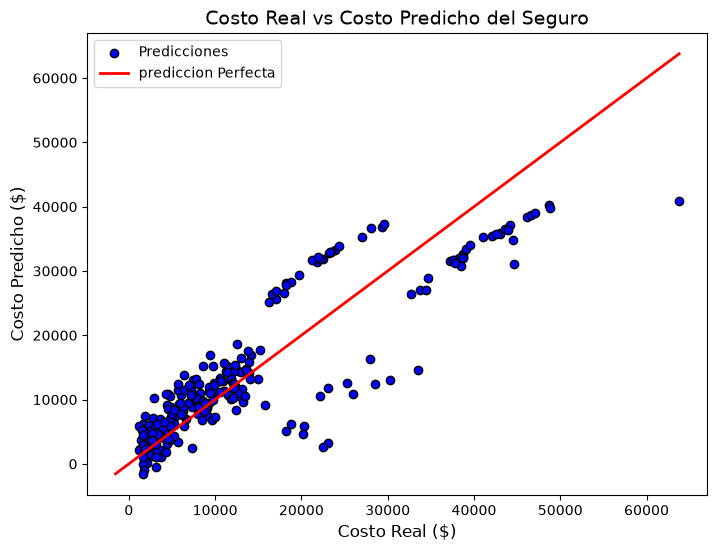

In [82]:
plt.figure(figsize=(8, 6))
plt.scatter(ytest, ypred, color='b', edgecolor='k', label='Predicciones')

min_val = min(min(ytest), min(ypred))
max_val = max(max(ytest), max(ypred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linewidth=2, label='prediccion Perfecta')

plt.title('Costo Real vs Costo Predicho del Seguro', fontsize=14)
plt.xlabel('Costo Real ($)', fontsize=12)
plt.ylabel('Costo Predicho ($)', fontsize=12)
plt.legend()


+ Mejor y peor rango: El modelo predice mejor en el rango bajo y moderado menos de 15_000, donde se concentra la mayor densidad de datos. Predice peor en el rango alto arriba de 17_000, donde los puntos se dispersan ampliamente.

+ Sobrestimar o subestimar: Los puntos mas alejados se ubican principalmente por debajo de la diagonal, lo que indica que el modelo subestima los costos reales (predice valores menores a los que realmente ocurrieron).

+ Grupos de puntos separados: si, reflejan subgrupos poblacionales con estructuras de costos distintas.

+ Hipotesis del error: Los mayores errores son provocados por los fumadores con costos elevados. El modelo lineal no capta por completo el salto exponencial que fumar provoca en los cargos medicos, generando severas subestimaciones en ese sector.

***PASO 9***

In [81]:
datos_nuevos = pd.DataFrame({
    'age': [45, 45, 25],
    'sex': ['male', 'male', 'female'],
    'bmi': [33.5, 33.5, 22.0],
    'children': [2, 2, 0],
    'smoker': ['yes', 'no', 'no'],
    'region': ['southeast', 'southeast', 'northwest']
})

x_nuevos = pd.get_dummies(datos_nuevos, drop_first=True)
x_nuevos = x_nuevos.reindex(columns=x.columns, fill_value=0)
predicciones = modelo.predict(x_nuevos)

for i, costo in enumerate(predicciones):
    print(f"Solicitante {i+1}: ${costo:,.2f}")

Solicitante 1: $34,750.52
Solicitante 2: $11,099.39
Solicitante 3: $1,909.21


+ Por qué es necesario el reindex = 
Asegura que el DataFrame nuevo tenga exactamente las mismas columnas, en el mismo orden, con las que el modelo fue entrenado (X.columns). Sin eso, `model.predict()` arrojaria un error de desalineacion de los datos, dando predicciones totalmente falsas.

+ Diferencia entre los solicitantes A y B:
Entre el Solicitante 1 y el Solicitante 2, la única diferencia es que el primero fuma (yes) y el segundo no (no), manteniendo exactamente los mismos valores en edad, sexo, IMC, hijos y region.

+ ¿Cuánto cambia la prediccion? Cambia en 23_651 (el costo del Solicitante 1 es mayor por esa cantidad).
+ ¿Qué coeficiente lo explica? El coeficiente de la variable smoker_yes. Al cambiar una variable binaria de 0 a 1, el impacto en la prediccion lineal es el valor de su coeficiente.